In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import math
import random
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms


# ============================================================
# CONFIG
# ============================================================

SEED = 42

IMAGE_SIZE = 28
N_PIXELS = IMAGE_SIZE * IMAGE_SIZE   # 784

# We discretize grayscale values.
#
# 32 bins is easier for this small MNIST experiment.
# If you want literal 8-bit pixel values, change this to 256.
N_BINS = 32

D_MODEL = 96
N_HEADS = 4
N_LAYERS = 3
MLP_RATIO = 4

DROPOUT = 0.1

BATCH_SIZE = 32
EPOCHS = 8

LR = 3e-4
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"


# ============================================================
# REPRODUCIBILITY
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True


print("Device:", DEVICE)

Device: cuda


In [2]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])


train_ds = datasets.MNIST(
    root="/kaggle/working/mnist",
    train=True,
    download=True,
    transform=transform,
)


test_ds = datasets.MNIST(
    root="/kaggle/working/mnist",
    train=False,
    download=True,
    transform=transform,
)


train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)


def quantize_images(x):
    """
    x:
        [B, 1, H, W]
        float values in [0,1]

    return:
        [B, H*W]
        integer pixel tokens in [0, N_BINS-1]
    """

    x = x.squeeze(1)

    q = torch.round(
        x * (N_BINS - 1)
    ).long()

    return q.flatten(1)


def dequantize_tokens(q):
    """
    Convert discrete pixel tokens back to [0,1].
    """

    return q.float() / (N_BINS - 1)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.89MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.61MB/s]


In [3]:
class CausalSelfAttention(nn.Module):

    def __init__(
        self,
        d_model,
        n_heads,
        dropout
    ):

        super().__init__()

        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.dropout = dropout

        self.qkv = nn.Linear(
            d_model,
            3 * d_model,
            bias=False
        )

        self.proj = nn.Linear(
            d_model,
            d_model,
            bias=False
        )


    def forward(
        self,
        x,
        cache=None,
        use_cache=False
    ):

        B, T, C = x.shape

        qkv = self.qkv(x)

        q, k, v = qkv.chunk(
            3,
            dim=-1
        )


        # [B,T,C]
        # ->
        # [B,heads,T,head_dim]

        q = q.view(
            B,
            T,
            self.n_heads,
            self.head_dim
        ).transpose(1, 2)

        k = k.view(
            B,
            T,
            self.n_heads,
            self.head_dim
        ).transpose(1, 2)

        v = v.view(
            B,
            T,
            self.n_heads,
            self.head_dim
        ).transpose(1, 2)


        # ====================================================
        # TRAINING / PREFIX PREFILL
        # ====================================================

        if cache is None:

            k_all = k
            v_all = v

            y = F.scaled_dot_product_attention(
                q,
                k_all,
                v_all,
                dropout_p=(
                    self.dropout
                    if self.training
                    else 0.0
                ),
                is_causal=True
            )


        # ====================================================
        # AUTOREGRESSIVE SAMPLING
        # ====================================================

        else:

            k_previous, v_previous = cache

            k_all = torch.cat(
                [k_previous, k],
                dim=2
            )

            v_all = torch.cat(
                [v_previous, v],
                dim=2
            )


            # During cached decoding we add exactly one
            # new token.
            #
            # Since it is the final token, it can see
            # everything in the cache.

            y = F.scaled_dot_product_attention(
                q,
                k_all,
                v_all,
                dropout_p=0.0,
                is_causal=False
            )


        y = y.transpose(
            1, 2
        ).contiguous()

        y = y.view(
            B,
            T,
            C
        )

        y = self.proj(y)


        if use_cache:
            new_cache = (
                k_all,
                v_all
            )
        else:
            new_cache = None


        return y, new_cache

In [4]:
class GPTBlock(nn.Module):

    def __init__(
        self,
        d_model,
        n_heads,
        mlp_ratio,
        dropout
    ):

        super().__init__()


        self.ln1 = nn.LayerNorm(
            d_model
        )

        self.attn = CausalSelfAttention(
            d_model,
            n_heads,
            dropout
        )


        self.ln2 = nn.LayerNorm(
            d_model
        )


        hidden = mlp_ratio * d_model


        self.mlp = nn.Sequential(

            nn.Linear(
                d_model,
                hidden
            ),

            nn.GELU(),

            nn.Linear(
                hidden,
                d_model
            ),

            nn.Dropout(
                dropout
            )
        )


    def forward(
        self,
        x,
        cache=None,
        use_cache=False
    ):

        attention_output, new_cache = self.attn(

            self.ln1(x),

            cache=cache,

            use_cache=use_cache
        )


        x = x + attention_output


        x = x + self.mlp(
            self.ln2(x)
        )


        return x, new_cache

In [5]:
class RandomOrderPixelTransformer(nn.Module):

    """
    Random-order autoregressive image model.

    For random permutation pi:

        [P(pi1), x(pi1),
         P(pi2), x(pi2),
         ...
         P(piN)]

    Hidden states at the P tokens predict
    their corresponding pixel values.
    """

    def __init__(
        self,
        image_size=28,
        n_bins=32,
        d_model=96,
        n_heads=4,
        n_layers=3,
        mlp_ratio=4,
        dropout=0.1
    ):

        super().__init__()


        self.image_size = image_size

        self.n_pixels = (
            image_size *
            image_size
        )

        self.n_bins = n_bins
        self.d_model = d_model


        # ====================================================
        # 2D LOCATION EMBEDDINGS
        # ====================================================

        self.row_embed = nn.Embedding(
            image_size,
            d_model
        )

        self.col_embed = nn.Embedding(
            image_size,
            d_model
        )


        # ====================================================
        # PIXEL VALUE EMBEDDINGS
        # ====================================================

        self.value_embed = nn.Embedding(
            n_bins,
            d_model
        )


        # Position-instruction token type.
        self.instruction_token = nn.Parameter(
            torch.randn(d_model) * 0.02
        )


        # Pixel-value token type.
        self.value_type = nn.Parameter(
            torch.randn(d_model) * 0.02
        )


        # ====================================================
        # TRANSFORMER
        # ====================================================

        self.blocks = nn.ModuleList([

            GPTBlock(
                d_model,
                n_heads,
                mlp_ratio,
                dropout
            )

            for _ in range(n_layers)

        ])


        self.final_ln = nn.LayerNorm(
            d_model
        )


        # Predict pixel probability distribution.
        self.lm_head = nn.Linear(
            d_model,
            n_bins,
            bias=False
        )


        self.apply(
            self._init_weights
        )


    # --------------------------------------------------------

    def _init_weights(
        self,
        module
    ):

        if isinstance(
            module,
            (nn.Linear, nn.Embedding)
        ):

            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )


        if (
            isinstance(module, nn.Linear)
            and
            module.bias is not None
        ):

            nn.init.zeros_(
                module.bias
            )


    # --------------------------------------------------------

    def spatial_embed(
        self,
        locations
    ):

        """
        locations:
            flattened pixel positions

            0 ... 783
        """

        rows = (
            locations //
            self.image_size
        )

        cols = (
            locations %
            self.image_size
        )


        return (

            self.row_embed(rows)

            +

            self.col_embed(cols)

        )


    # --------------------------------------------------------

    def embed_instruction(
        self,
        locations
    ):

        """
        P(location)
        """

        return (

            self.spatial_embed(
                locations
            )

            +

            self.instruction_token
        )


    # --------------------------------------------------------

    def embed_value(
        self,
        locations,
        values
    ):

        """
        x(location)
        """

        return (

            self.spatial_embed(
                locations
            )

            +

            self.value_embed(
                values
            )

            +

            self.value_type
        )


    # --------------------------------------------------------

    def run_embeddings(
        self,
        x,
        cache=None,
        use_cache=False
    ):

        new_caches = []


        for i, block in enumerate(
            self.blocks
        ):

            if cache is None:
                layer_cache = None
            else:
                layer_cache = cache[i]


            x, c = block(

                x,

                cache=layer_cache,

                use_cache=use_cache
            )


            if use_cache:
                new_caches.append(c)


        x = self.final_ln(x)


        if use_cache:
            return x, new_caches

        return x, None


    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    def forward(
        self,
        pixel_tokens,
        permutation=None
    ):

        """
        pixel_tokens:

            [B, 784]

        Returns:

            logits:
                [B, 784, N_BINS]

            targets:
                [B, 784]
        """


        B, N = pixel_tokens.shape


        assert N == self.n_pixels


        # ====================================================
        # RANDOM PIXEL ORDER
        # ====================================================

        if permutation is None:

            permutation = torch.rand(
                B,
                N,
                device=pixel_tokens.device
            ).argsort(
                dim=1
            )


        # Rearrange image pixels according to pi.

        targets = torch.gather(
            pixel_tokens,
            dim=1,
            index=permutation
        )


        # ====================================================
        # POSITION INSTRUCTION TOKENS
        #
        # P(pi1), P(pi2), ..., P(piN)
        # ====================================================

        instruction_embeddings = (
            self.embed_instruction(
                permutation
            )
        )


        # ====================================================
        # PIXEL VALUE TOKENS
        #
        # x(pi1), ..., x(piN-1)
        # ====================================================

        value_locations = (
            permutation[:, :-1]
        )


        value_tokens = (
            targets[:, :-1]
        )


        value_embeddings = (
            self.embed_value(

                value_locations,

                value_tokens
            )
        )


        # ====================================================
        # INTERLEAVE
        #
        # P1, x1,
        # P2, x2,
        # ...
        # PN
        # ====================================================


        pairs = torch.stack(

            [

                instruction_embeddings[:, :-1],

                value_embeddings

            ],

            dim=2

        )


        pairs = pairs.reshape(

            B,

            2 * (N - 1),

            self.d_model
        )


        sequence = torch.cat(

            [

                pairs,

                instruction_embeddings[:, -1:]

            ],

            dim=1
        )


        # sequence length:
        #
        # 2*N - 1
        #
        # for MNIST:
        #
        # 1567 tokens


        hidden, _ = (
            self.run_embeddings(
                sequence
            )
        )


        # ====================================================
        # ONLY P TOKENS PREDICT PIXELS
        #
        # positions:
        #
        # 0,2,4,6,...
        # ====================================================

        instruction_hidden = (
            hidden[:, 0::2, :]
        )


        logits = self.lm_head(
            instruction_hidden
        )


        return (
            logits,
            targets,
            permutation
        )


    # ========================================================
    # INFERENCE
    # ========================================================

    @torch.no_grad()
    def prefill_known(
        self,
        known_locations,
        known_values
    ):

        """
        Construct:

        P(k1), x(k1),
        P(k2), x(k2),
        ...
        """


        if known_locations.numel() == 0:

            return None


        instructions = (
            self.embed_instruction(

                known_locations[None, :]

            )
        )


        values = self.embed_value(

            known_locations[None, :],

            known_values[None, :]
        )


        prefix = torch.stack(

            [

                instructions,

                values

            ],

            dim=2
        )


        prefix = prefix.reshape(

            1,

            2 * known_locations.numel(),

            self.d_model
        )


        _, cache = (
            self.run_embeddings(

                prefix,

                cache=None,

                use_cache=True
            )
        )


        return cache


    # --------------------------------------------------------

    @torch.no_grad()
    def query_location(
        self,
        location,
        cache
    ):

        """
        Add:

            P(location)

        and predict:

            p(pixel_value | previous context)
        """


        location = location.view(
            1, 1
        )


        x = self.embed_instruction(
            location
        )


        hidden, new_cache = (
            self.run_embeddings(

                x,

                cache=cache,

                use_cache=True
            )
        )


        logits = self.lm_head(

            hidden[:, -1, :]

        )


        return logits, new_cache


    # --------------------------------------------------------

    @torch.no_grad()
    def append_value(
        self,
        location,
        value,
        cache
    ):

        """
        Once x(location) is sampled,
        append it to the causal context.
        """


        location = location.view(
            1, 1
        )


        value = value.view(
            1, 1
        )


        x = self.embed_value(

            location,

            value
        )


        _, new_cache = (
            self.run_embeddings(

                x,

                cache=cache,

                use_cache=True
            )
        )


        return new_cache

In [6]:
model = RandomOrderPixelTransformer(

    image_size=IMAGE_SIZE,

    n_bins=N_BINS,

    d_model=D_MODEL,

    n_heads=N_HEADS,

    n_layers=N_LAYERS,

    mlp_ratio=MLP_RATIO,

    dropout=DROPOUT

).to(DEVICE)


n_parameters = sum(
    p.numel()
    for p in model.parameters()
)


print(
    f"Parameters: "
    f"{n_parameters / 1e6:.2f} M"
)

Parameters: 0.35 M


In [7]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LR,

    weight_decay=WEIGHT_DECAY
)


scaler = torch.cuda.amp.GradScaler(
    enabled=USE_AMP
)


history = []


for epoch in range(
    1,
    EPOCHS + 1
):

    model.train()

    running_loss = 0.0


    for step, (
        images,
        labels
    ) in enumerate(
        train_loader,
        start=1
    ):


        images = images.to(
            DEVICE,
            non_blocking=True
        )


        # -----------------------------------------------
        # Turn images into discrete pixel tokens
        # -----------------------------------------------

        tokens = quantize_images(
            images
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        # -----------------------------------------------
        # RANDOM ORDER IS CREATED INSIDE model()
        # -----------------------------------------------

        with torch.autocast(

            device_type=DEVICE.type,

            dtype=torch.float16,

            enabled=USE_AMP

        ):


            logits, targets, permutation = (
                model(tokens)
            )


            # ===========================================
            # CAUSAL NEXT-PIXEL LOSS
            # ===========================================

            loss = F.cross_entropy(

                logits.reshape(
                    -1,
                    N_BINS
                ),

                targets.reshape(-1)
            )


        # -----------------------------------------------
        # Backpropagation
        # -----------------------------------------------

        scaler.scale(
            loss
        ).backward()


        scaler.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            GRAD_CLIP
        )


        scaler.step(
            optimizer
        )


        scaler.update()


        running_loss += (
            loss.item()
        )


        if step % 200 == 0:

            print(

                f"epoch {epoch:02d} | "

                f"step "
                f"{step:04d}/"
                f"{len(train_loader)} | "

                f"loss "
                f"{running_loss/step:.4f}"
            )


    epoch_loss = (
        running_loss /
        len(train_loader)
    )


    history.append(
        epoch_loss
    )


    print(
        f"\nEpoch {epoch:02d} finished"
        f" | loss = {epoch_loss:.4f}\n"
    )

/tmp/ipykernel_58/2211375311.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(


epoch 01 | step 0200/1875 | loss 1.0229
epoch 01 | step 0400/1875 | loss 0.9021
epoch 01 | step 0600/1875 | loss 0.8117
epoch 01 | step 0800/1875 | loss 0.7525
epoch 01 | step 1000/1875 | loss 0.7138
epoch 01 | step 1200/1875 | loss 0.6868
epoch 01 | step 1400/1875 | loss 0.6661
epoch 01 | step 1600/1875 | loss 0.6496
epoch 01 | step 1800/1875 | loss 0.6360

Epoch 01 finished | loss = 0.6315

epoch 02 | step 0200/1875 | loss 0.5158
epoch 02 | step 0400/1875 | loss 0.5150
epoch 02 | step 0600/1875 | loss 0.5136
epoch 02 | step 0800/1875 | loss 0.5122
epoch 02 | step 1000/1875 | loss 0.5109
epoch 02 | step 1200/1875 | loss 0.5094
epoch 02 | step 1400/1875 | loss 0.5079
epoch 02 | step 1600/1875 | loss 0.5066
epoch 02 | step 1800/1875 | loss 0.5053

Epoch 02 finished | loss = 0.5048

epoch 03 | step 0200/1875 | loss 0.4894
epoch 03 | step 0400/1875 | loss 0.4889
epoch 03 | step 0600/1875 | loss 0.4875
epoch 03 | step 0800/1875 | loss 0.4870
epoch 03 | step 1000/1875 | loss 0.4861
epoch 03

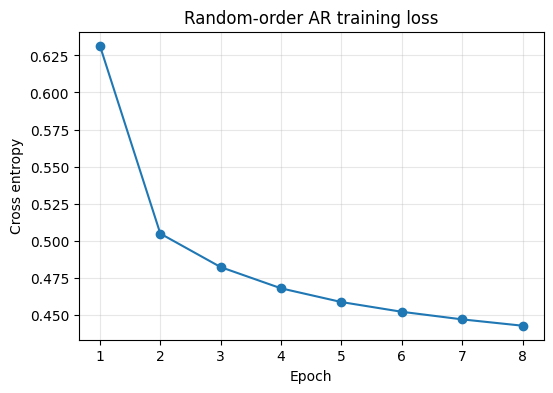

In [8]:
plt.figure(
    figsize=(6, 4)
)

plt.plot(
    range(
        1,
        len(history) + 1
    ),
    history,
    marker="o"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Cross entropy"
)

plt.title(
    "Random-order AR training loss"
)

plt.grid(
    alpha=0.3
)

plt.show()

In [9]:
torch.save(

    {

        "model": model.state_dict(),

        "config": {

            "IMAGE_SIZE": IMAGE_SIZE,

            "N_BINS": N_BINS,

            "D_MODEL": D_MODEL,

            "N_HEADS": N_HEADS,

            "N_LAYERS": N_LAYERS
        }

    },

    "/kaggle/working/random_order_mnist_transformer.pt"
)

In [10]:
def sample_categorical(
    logits,
    temperature=1.0,
    top_k=None
):

    logits = logits / max(
        temperature,
        1e-6
    )


    if top_k is not None:

        k = min(
            top_k,
            logits.shape[-1]
        )


        values, _ = torch.topk(

            logits,

            k=k,

            dim=-1
        )


        cutoff = (
            values[:, -1:]
        )


        logits = torch.where(

            logits < cutoff,

            torch.full_like(
                logits,
                -float("inf")
            ),

            logits
        )


    probabilities = F.softmax(

        logits,

        dim=-1
    )


    sample = torch.multinomial(

        probabilities,

        num_samples=1
    )


    return sample.squeeze()

In [26]:
@torch.no_grad()
def complete_image(

    model,

    ground_truth_tokens,

    known_mask,

    temperature=0.9,

    top_k=8,

    shuffle_known=True,

    shuffle_unknown=True
):

    """

    ground_truth_tokens:
        [H,W]

    known_mask:
        [H,W]

        True  = model gets this pixel
        False = model must generate it

    """


    model.eval()


    H = W = model.image_size


    flat_gt = (
        ground_truth_tokens
        .flatten()
        .to(DEVICE)
    )


    flat_mask = (
        known_mask
        .flatten()
        .to(DEVICE)
    )


    # ========================================================
    # OBSERVED PIXELS
    # ========================================================

    known_locations = torch.where(
        flat_mask
    )[0]


    # ========================================================
    # PIXELS TO GENERATE
    # ========================================================

    unknown_locations = torch.where(
        ~flat_mask
    )[0]


    # Randomize known prefix order.

    if (
        shuffle_known
        and
        known_locations.numel() > 0
    ):

        order = torch.randperm(

            known_locations.numel(),

            device=DEVICE
        )


        known_locations = (
            known_locations[order]
        )


    # Random generation order.

    if (
        shuffle_unknown
        and
        unknown_locations.numel() > 0
    ):

        order = torch.randperm(

            unknown_locations.numel(),

            device=DEVICE
        )


        unknown_locations = (
            unknown_locations[order]
        )


    known_values = (
        flat_gt[known_locations]
    )


    # ========================================================
    # OUTPUT IMAGE
    # ========================================================

    output = torch.zeros_like(
        flat_gt
    )


    # Keep observed pixels exactly fixed.

    output[known_locations] = (
        known_values
    )


    # ========================================================
    # PREFIX
    #
    # known pixels first:
    #
    # P_known, x_known,
    # P_known, x_known,
    # ...
    # ========================================================

    cache = model.prefill_known(

        known_locations,

        known_values
    )


    # ========================================================
    # GENERATE UNKNOWN PIXELS
    # ========================================================

    for location in unknown_locations:


        # -----------------------------------------------
        # Ask:
        #
        # what should pixel at LOCATION be?
        # -----------------------------------------------

        logits, cache = (
            model.query_location(

                location,

                cache
            )
        )


        # -----------------------------------------------
        # SAMPLE from the probability distribution.
        # -----------------------------------------------

        value = sample_categorical(

            logits,

            temperature=temperature,

            top_k=top_k
        )


        output[location] = (
            value
        )


        # -----------------------------------------------
        # Newly generated pixel becomes known context.
        # -----------------------------------------------

        cache = model.append_value(

            location,

            value,

            cache
        )


    return (

        output

        .view(H, W)

        .cpu()
    )

In [27]:
def left_half_known_mask(
    size=28
):

    mask = torch.zeros(
        size,
        size,
        dtype=torch.bool
    )

    mask[
        :,
        :size // 2
    ] = True

    return mask

In [28]:
def outside_center_known_mask(
    size=28,
    hole_size=12
):

    mask = torch.ones(
        size,
        size,
        dtype=torch.bool
    )


    start = (
        size - hole_size
    ) // 2

    end = (
        start +
        hole_size
    )


    mask[
        start:end,
        start:end
    ] = False


    return mask

In [29]:
def random_known_mask(
    size=28,
    known_fraction=0.20
):

    return (

        torch.rand(
            size,
            size
        )

        <

        known_fraction
    )

In [30]:
test_index = 12


image, label = (
    test_ds[test_index]
)


gt_tokens = quantize_images(

    image.unsqueeze(0)

)[0]


gt_tokens = gt_tokens.view(

    IMAGE_SIZE,

    IMAGE_SIZE
)


print(
    "True label:",
    label
)

True label: 9


In [31]:
#known_mask = (
#    left_half_known_mask(
#        IMAGE_SIZE
#    )
#)

In [32]:
known_mask = outside_center_known_mask(
     IMAGE_SIZE,
     hole_size=12
 )

In [33]:
sample_1 = complete_image(

    model,

    gt_tokens,

    known_mask,

    temperature=0.9,

    top_k=8
)


sample_2 = complete_image(

    model,

    gt_tokens,

    known_mask,

    temperature=1.0,

    top_k=12
)

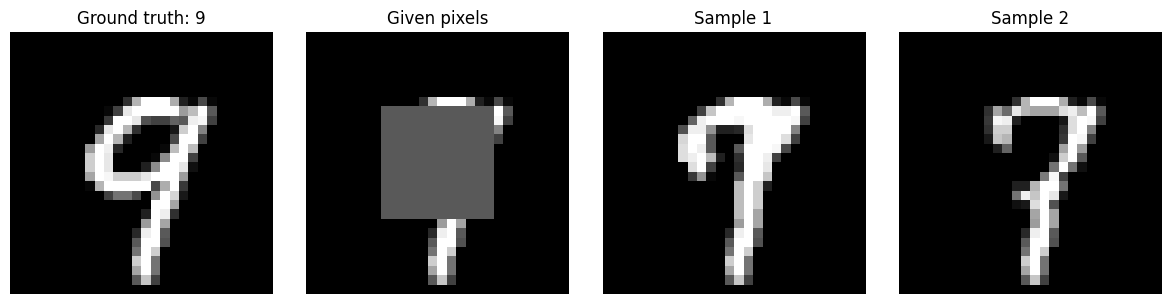

In [35]:
gt_image = (
    dequantize_tokens(
        gt_tokens
    ).cpu()
)


# ============================================================
# DISPLAY THE CONDITIONING IMAGE
# ============================================================

observed = (
    gt_image.clone()
)


# Gray means unknown.
#
# IMPORTANT:
# This gray value is ONLY for visualization.
# The model never receives it.

observed[
    ~known_mask
] = 0.35


sample_1_image = (
    dequantize_tokens(
        sample_1
    )
)


sample_2_image = (
    dequantize_tokens(
        sample_2
    )
)


# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(

    1,
    4,

    figsize=(12, 3)
)


axes[0].imshow(

    gt_image,

    cmap="gray",

    vmin=0,
    vmax=1
)

axes[0].set_title(
    f"Ground truth: {label}"
)


axes[1].imshow(

    observed,

    cmap="gray",

    vmin=0,
    vmax=1
)

axes[1].set_title(
    "Given pixels"
)


axes[2].imshow(

    sample_1_image,

    cmap="gray",

    vmin=0,
    vmax=1
)

axes[2].set_title(
    "Sample 1"
)


axes[3].imshow(

    sample_2_image,

    cmap="gray",

    vmin=0,
    vmax=1
)

axes[3].set_title(
    "Sample 2"
)


for ax in axes:
    ax.axis("off")


plt.tight_layout()

plt.show()